RMS difference between model and measured ORM: 4.529e-05 m
Plot saved to: output/orms_comparison.png


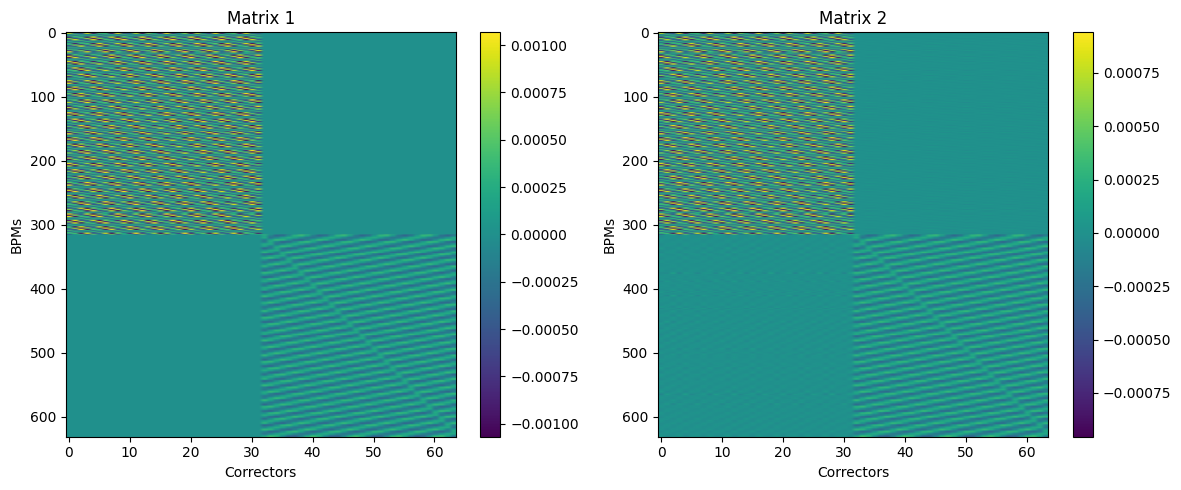

In [33]:
import os
import h5py
import numpy as np
import at
from pyLOCO.helpers import load_config
from pyLOCO.pyloco import remove_bad_bpms, pyloco, plot_matrices,last_by_sorted_key, get_quads_block, plot_data, save_fit_dict
from pyLOCO.response_matrix import response_matrix
from pyloco_config import FitInitConfig, RMConfig, fixed_parameters, loco_options

# --- Load configuration ---
config_path = os.path.abspath("pyloco_config.py")
load_config(config_path=config_path)

# --- Load lattice ---
ring = at.load_lattice('betamodel.mat', use='betamodel')
ring.disable_6d()
# --- Get element indices ---
elements_ind = at.get_refpts(ring, "*")
cor_indices = at.get_refpts(ring, 'S[FIJ]2A*')
Corords = [cor_indices,cor_indices]
used_bpm = at.get_refpts(ring, at.elements.Monitor)
quad_indices = at.get_refpts(ring, at.elements.Quadrupole)
QD3 = at.get_refpts(ring, 'QD3[AE]*')
QF4 = at.get_refpts(ring, 'QF4[ABDE]*')
QD5 = at.get_refpts(ring, 'QD5[BD]*')
combined = np.concatenate((QD3, QF4, QD5))
quad_indices = np.sort(combined)
CAVords = at.get_refpts(ring, at.elements.RFCavity)
sext_indices = at.get_refpts(ring, at.elements.Sextupole)
skew_ord = at.get_refpts(ring, 'S[HFDIJ]*')

# --- Load measurements ---
with h5py.File("./data/ORM_for_pyLOCO_20260116_191907.h5", "r") as f:
    measured_orm = np.array(f["response_matrix"])  # [BPMs x COR]
    delta_correctors = np.array(f["full_delta"])

with h5py.File("./data/measured_dispersion_loco_20260116_184500.h5", "r") as f:
    measured_eta_x_ = np.array(f["measured_eta_x"])
    measured_eta_y_ = np.array(f["measured_eta_y"])
    rf_full_step = np.array(f.attrs["rf_full_step"])

with h5py.File("./data/measured_BPM_noise_loco_20260116_184300.h5", "r") as f:  # in meter
    Noise_BPMx = np.array(f["Noise_BPMx"])
    Noise_BPMy = np.array(f["Noise_BPMy"])

# --- Remove bad BPMs ---
bad_bpm_positions = np.array([27, 33, 157, 286]) # remove 58

used_bpms_ords = np.delete(used_bpm, bad_bpm_positions)
Noise_BPMx_cleaned = np.delete(Noise_BPMx, bad_bpm_positions)
Noise_BPMy_cleaned = np.delete(Noise_BPMy, bad_bpm_positions)
sigma_w = np.concatenate((Noise_BPMx_cleaned, Noise_BPMy_cleaned))[:,
          np.newaxis]  # Note: weight matrix shape for pyloco

measured_eta_x = np.delete(measured_eta_x_, bad_bpm_positions)
measured_eta_y = np.delete(measured_eta_y_, bad_bpm_positions)
eta = np.concatenate([measured_eta_x, measured_eta_y])


measured_orm, removed = remove_bad_bpms(
    measured_orm,
    bad_bpm_positions,
    total_bpms=len(used_bpm),
    axis=0,
    input_type="positions"
)

# if include dispersion is true
#measured_orm = np.hstack((measured_orm, eta.reshape(-1, 1)))

# --- Prepare configuration for model ORM ---

CMstep = [[delta_correctors] * len(Corords[0]), [delta_correctors] * len(Corords[1])]

fit_cfg = FitInitConfig()
includeDispersion = False
HCMCoupling = np.zeros(len(Corords[0]))
VCMCoupling = np.zeros(len(Corords[1]))

cfg = RMConfig(
    dkick=CMstep,
    bpm_ords=used_bpms_ords,
    cm_ords=Corords,
    HCMCoupling=HCMCoupling,
    VCMCoupling=VCMCoupling,
    rfStep=rf_full_step,
    includeDispersion=includeDispersion
)

# --- Compute model ORM ---

orm_model = response_matrix(ring, config=cfg)
rms_diff = np.sqrt(np.mean((orm_model - measured_orm)**2))
print(f"RMS difference between model and measured ORM: {rms_diff:.3e} m")
os.makedirs("output", exist_ok=True)
plot_matrices(orm_model, measured_orm, titles=None, cmap='viridis', plot_type='2d', save_path="output/orms_comparison.png")

In [49]:
with h5py.File("./data/measured_dispersion_loco_20260116_184500.h5", "r") as f:
    measured_eta_x_ = np.array(f["measured_eta_x"])
    measured_eta_y_ = np.array(f["measured_eta_y"])
    rf_full_step = np.array(f.attrs["rf_full_step"])


with h5py.File("./data/measured_dispersion_loco_20260116_211800.h5", "r") as f:
    measured_eta_x_2 = np.array(f["measured_eta_x"])
    measured_eta_y_2 = np.array(f["measured_eta_y"])
    rf_full_step = np.array(f.attrs["rf_full_step"])


In [53]:
s_pos = twiss_err.s_pos
_, _, twiss = at.get_optics(ring, used_bpm)
dx = (twiss_err.dispersion[:, 0] - twiss.dispersion[:, 0]) #/ twiss.beta[:, 0]
dy = (twiss_err.dispersion[:, 2] - twiss.dispersion[:, 2]) #/ twiss.beta[:, 1]

ValueError: operands could not be broadcast together with shapes (4432,) (320,) 

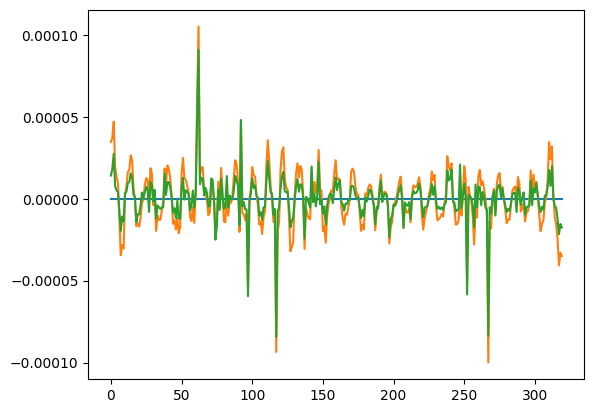

In [62]:
plt.plot(twiss.dispersion[:, 2])
plt.plot(measured_eta_y_)
plt.plot(measured_eta_y_2)

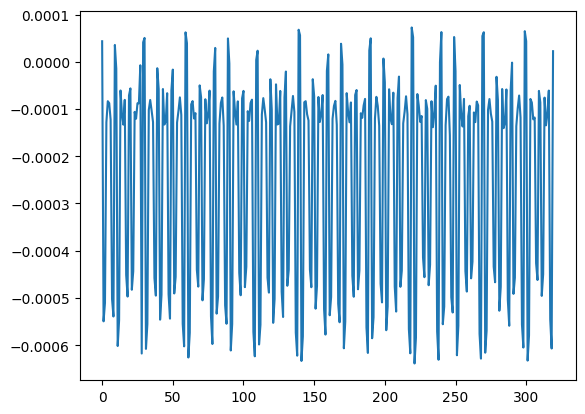

In [58]:
plt.plot(measured_eta_x_)

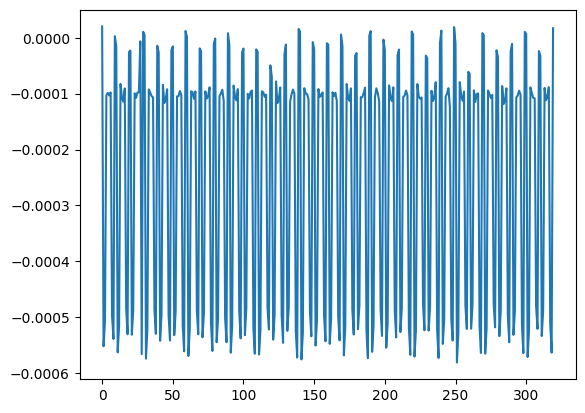

In [59]:
plt.plot(measured_eta_x_2)

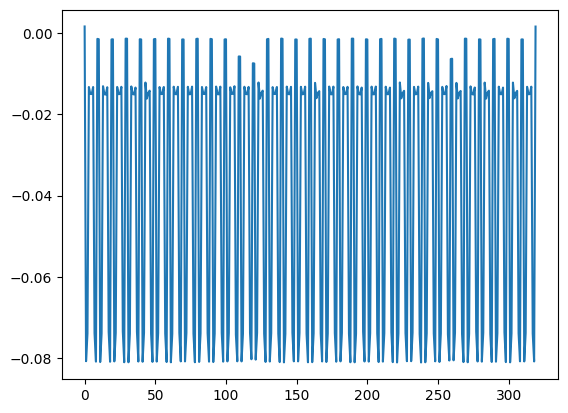

In [56]:
plt.plot(measured_eta_x_ - twiss.dispersion[:, 0])

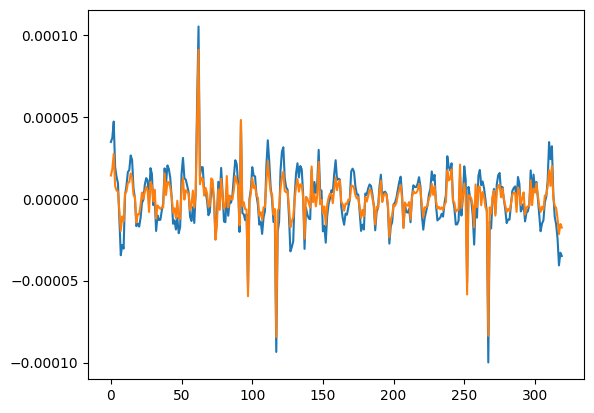

In [52]:
plt.plot(measured_eta_y_)
plt.plot(measured_eta_y_2)

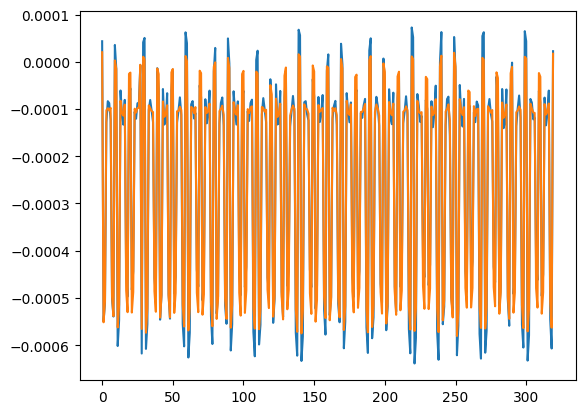

In [51]:
plt.plot(measured_eta_x_)
plt.plot(measured_eta_x_2)


In [34]:
np.shape(measured_orm)

(632, 64)

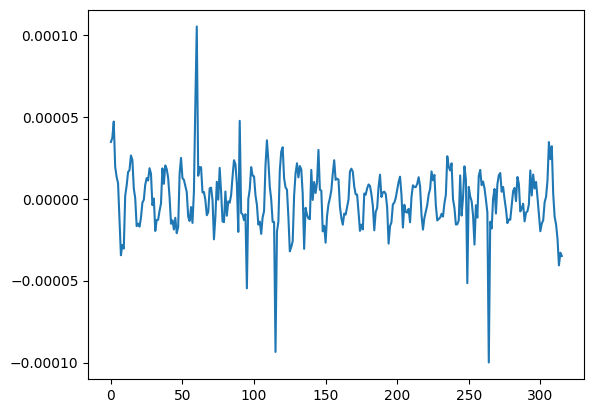

In [9]:
import matplotlib.pyplot as plt
plt.plot(measured_eta_y)


==== Iteration 1/2 – LM ====
   No outliers in the data set.
Initial Chi²: 3.9611e+04


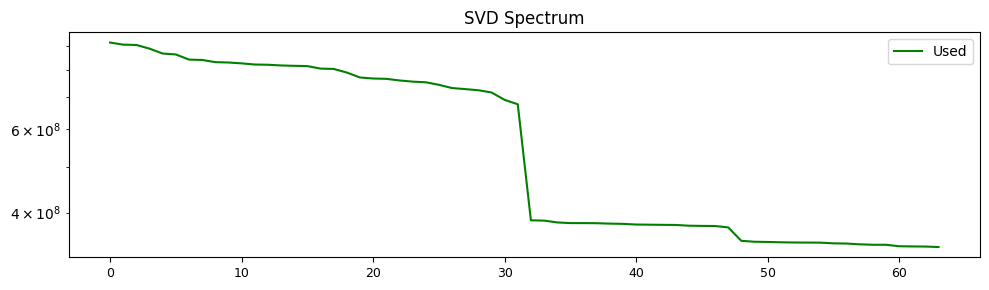

  LM inner 1: chi² 3.9656e+03 (previous 3.9611e+04), λ=0.001
Chi² after correction: 3.9656e+03

==== Iteration 2/2 – LM ====
   No outliers in the data set.
Initial Chi²: 3.9656e+03


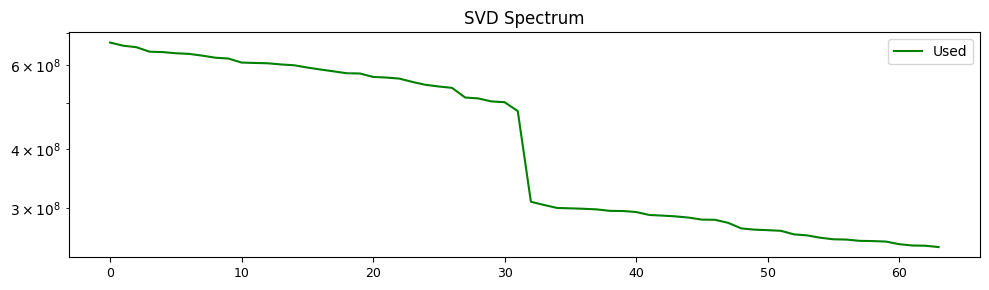

  LM inner 1: chi² 3.9656e+03 (previous 3.9656e+03), λ=0.001
Chi² after correction: 3.9656e+03
LOCO LM completed! :).
[info] Saved fit_dict to output_all_err/fit_results_all_parameters.json


In [18]:
fit_cfg = FitInitConfig()
ring.disable_6d()
# --- define arguments ---
measured_orm = np.hstack((measured_orm, eta.reshape(-1, 1)))

nHorCOR = len(Corords[0])
nVerCOR = len(Corords[1])
nHBPM = nVBPM = len(used_bpms_ords)
nIter = 2

fit_list     = [
    #"quads",
    #'skew_quads' ,
    #'quads_tilt' ,
    #"hbpm_gain",
    #"vbpm_gain",
    "hcor_cal",
    "vcor_cal",
   # 'hbpm_coupling',
   # 'vbpm_coupling',
   # 'hcor_coupling',
   # 'vcor_coupling',
]


remove_coupling_ = True
includeDispersion = False
fixedpathlength = True
fixedmomentum = False
hor_dispersion_weight=1
ver_dispersion_weight=1

fit_results, fit_dict, ring_pyloco = pyloco(
    ring,

    # --- general control ---
    algorithm=loco_options.algorithm,
    nIter= nIter,

    # --- indices & number of elements ---
    used_bpms_ords=used_bpms_ords,
    used_cor_ords=Corords,
    quads_ords=quad_indices,
    skew_ords=skew_ord,
    CAVords=CAVords,
    nHBPM=nHBPM,
    nVBPM=nVBPM,
    nHorCOR=nHorCOR,
    nVerCOR=nVerCOR,
    quads_tilt_ind=quad_indices,
    inetial_fit_parameters=None,

    # --- measurement data ---
    orm_measured=measured_orm,
    weights=sigma_w,
    includeDispersion=includeDispersion,
    measured_eta_x=measured_eta_x,
    measured_eta_y=measured_eta_y,
    hor_dispersion_weight=hor_dispersion_weight,
    ver_dispersion_weight=ver_dispersion_weight,

    # --- correctors kicks & RF ---
    CMstep=CMstep,
    rfStep=rf_full_step,
    Frequency=fixed_parameters.Frequency,

    # --- features ---
    fit_list=fit_list,
    individuals=loco_options.individuals,
    remove_coupling_= remove_coupling_,

    # --- outliers & normalization ---
    outlier_rejection=loco_options.outlier_rejection,
    sigma_outlier=loco_options.sigma_outlier,
    apply_normalization=loco_options.apply_normalization,
    normalization_mode=loco_options.normalization_mode,

    # --- SVD selection ---
    svd_selection_method= 'user_input',
    svd_threshold = 32,#64,
    cut_=loco_options.cut_,
    show_svd_plot=loco_options.show_svd_plot,

    # --- LM options ---
    nLMIter=loco_options.nLMIter,
    Starting_Lambda=loco_options.Starting_Lambda,
    max_lm_lambda=loco_options.max_lm_lambda,
    scaled=loco_options.scaled,

    # --- more options ---
    plot_fit_parameters=loco_options.plot_fit_parameters,
    auto_correct_delta=loco_options.auto_correct_delta,
    fixedpathlength= fixedpathlength,
    fit_cfg=fit_cfg,
    fixedmomentum=fixedmomentum,

    # --- Jacopians files ---

    quad_jacobian_file="output_all_err/jacobians/quads/J_quads_iter1_0.0001urad_200Hz.h5",
    skew_jacobian_file=None,
    quads_tilt_jacobian_file=None,
    force_recompute=True
)

# --- save results ---
from pathlib import Path
save_fit_dict(fit_dict, Path("./output_all_err/fit_results_all_parameters"))
ring_pyloco.save('./output_all_err/ring_pyloco.mat', mat_key='ring')

[pyloco] Continuing from previous iteration set...
[pyloco] Building initial vector from previous stage...

==== Iteration 1/2 – LM ====
   No outliers in the data set.
Initial Chi²: 9.9223e+03


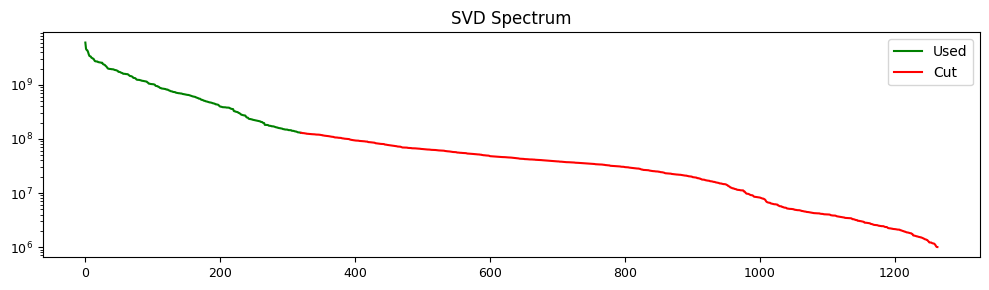

  LM inner 1: chi² 7.1866e+03 (previous 9.9223e+03), λ=0.001
Chi² after correction: 7.1866e+03

==== Iteration 2/2 – LM ====
   No outliers in the data set.
Initial Chi²: 7.1866e+03


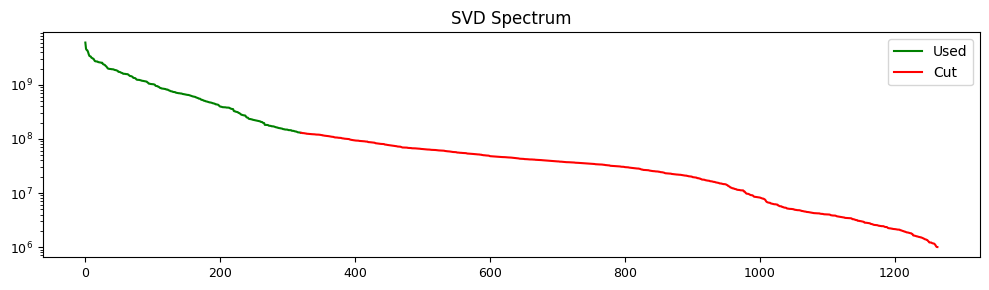

  LM inner 1: chi² 7.1890e+03 (previous 7.1866e+03), λ=0.001


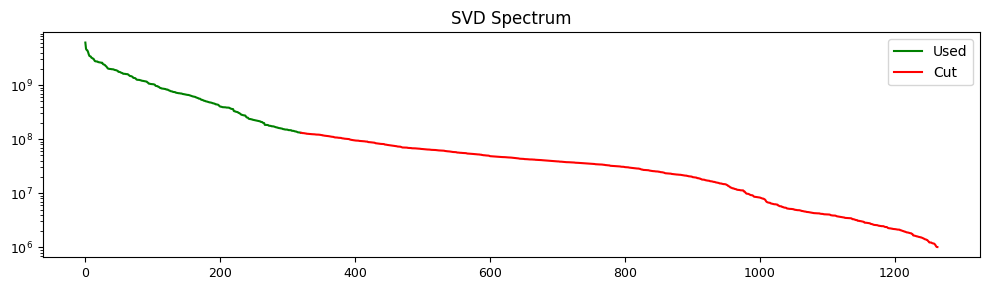

  LM inner 2: chi² 7.1890e+03 (previous 7.1866e+03), λ=0.01


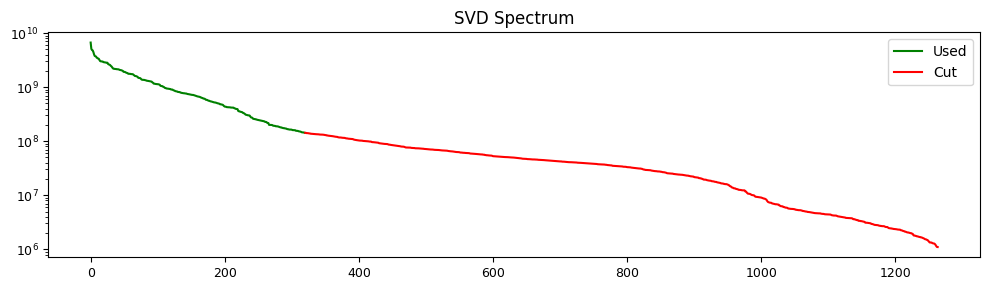

  LM inner 3: chi² 7.1888e+03 (previous 7.1866e+03), λ=0.1


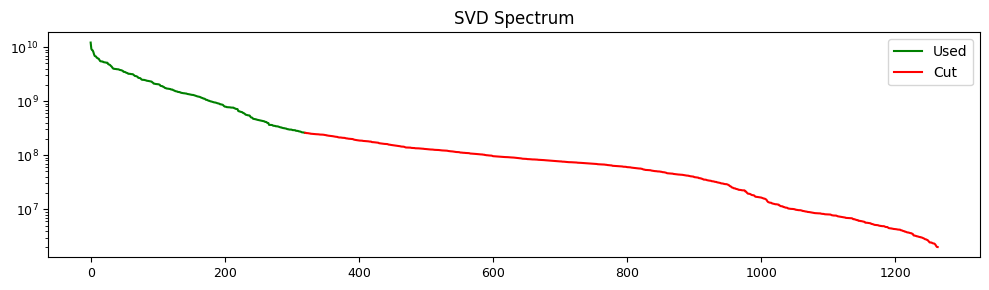

  LM inner 4: chi² 7.1878e+03 (previous 7.1866e+03), λ=1


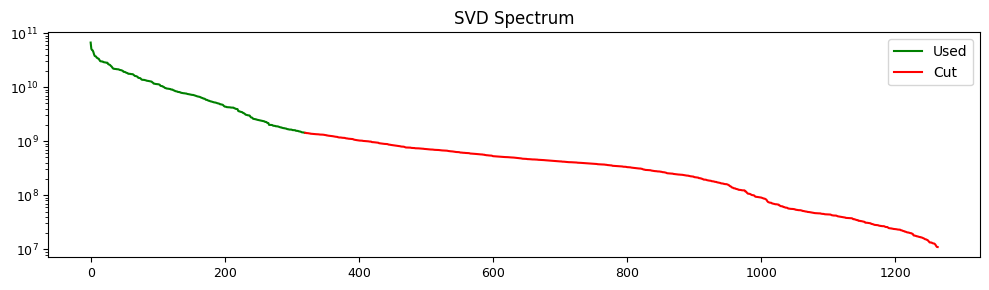

  LM inner 5: chi² 7.1869e+03 (previous 7.1866e+03), λ=10
  λ exceeded maximum; stop inner loop.
Chi² after correction: 7.1866e+03
LOCO LM completed! :).
[info] Saved fit_dict to output_all_err2/fit_results_all_parameters2.json


In [19]:
# In[2]:

fit_cfg = FitInitConfig()
ring.disable_6d()
# --- define arguments ---

nHorCOR = len(Corords[0])
nVerCOR = len(Corords[1])
nHBPM = nVBPM = len(used_bpms_ords)
nIter = 2


fit_list     = [
    #"quads",
    #'skew_quads' ,
    #'quads_tilt' ,
    "hbpm_gain",
    "vbpm_gain",
    #"hcor_cal",
    #"vcor_cal",
    'hbpm_coupling',
    'vbpm_coupling',
    #'hcor_coupling',
    #'vcor_coupling',
    #'delta_rf'
]

remove_coupling_ = False
includeDispersion = True

hor_dispersion_weight = 10
ver_dispersion_weight = 10

fit_results2, fit_dict2, ring_pyloco2 = pyloco(
    ring_pyloco,

    # --- general control ---
    algorithm=loco_options.algorithm,
    nIter= nIter,

    # --- indices & number of elements ---
    used_bpms_ords=used_bpms_ords,
    used_cor_ords=Corords,
    quads_ords=quad_indices,
    skew_ords=skew_ord,
    CAVords=CAVords,
    nHBPM=nHBPM,
    nVBPM=nVBPM,
    nHorCOR=nHorCOR,
    nVerCOR=nVerCOR,
    quads_tilt_ind=quad_indices,
    inetial_fit_parameters=None,

    # --- measurement data ---
    orm_measured=measured_orm,
    weights=sigma_w,
    includeDispersion=includeDispersion,
    measured_eta_x=measured_eta_x,
    measured_eta_y=measured_eta_y,
    hor_dispersion_weight=hor_dispersion_weight,
    ver_dispersion_weight=ver_dispersion_weight,

    # --- correctors kicks & RF ---
    CMstep=CMstep,
    rfStep=rf_full_step,
    Frequency=fixed_parameters.Frequency,

    # --- features ---
    fit_list=fit_list,
    individuals=loco_options.individuals,
    remove_coupling_= remove_coupling_,

    # --- outliers & normalization ---
    outlier_rejection=loco_options.outlier_rejection,
    sigma_outlier=loco_options.sigma_outlier,
    apply_normalization=loco_options.apply_normalization,
    normalization_mode=loco_options.normalization_mode,

    # --- SVD selection ---
    svd_selection_method="user_input",
    svd_threshold = loco_options.svd_threshold,
    cut_= 320, #1280,
    show_svd_plot=loco_options.show_svd_plot,

    # --- LM options ---
    nLMIter=loco_options.nLMIter,
    Starting_Lambda=loco_options.Starting_Lambda,
    max_lm_lambda=loco_options.max_lm_lambda,
    scaled=loco_options.scaled,

    # --- more options ---
    plot_fit_parameters=loco_options.plot_fit_parameters,
    auto_correct_delta=loco_options.auto_correct_delta,
    fixedpathlength= fixedpathlength,
    fit_cfg=fit_cfg,
     fixedmomentum=fixedmomentum,

    # --- Jacopians files ---

    quad_jacobian_file="output_all_err/jacobians/quads/J_quads_iter1_0.0001urad_200Hz.h5",
    skew_jacobian_file=None,
    quads_tilt_jacobian_file=None,
    force_recompute=True,

    continue_from_previous=True,
    previous_fit_results=fit_results,
    previous_fit_dict=fit_dict,
    previous_ring=ring_pyloco
)

# --- save results ---
from pathlib import Path
save_fit_dict(fit_dict2, Path("./output_all_err2/fit_results_all_parameters2"))
ring_pyloco2.save('./output_all_err2/ring_pyloco2.mat', mat_key='ring')

[pyloco] Continuing from previous iteration set...
[pyloco] Building initial vector from previous stage...

==== Iteration 1/2 – LM ====
[Jacobian] File exists, but recomputing as requested (force_recompute=True).
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/EBS/EBS_MDT_16Jan_2026/output/quad_jacobian_logs2.txt'
[Jacobian] Saved normal-quadrupole Jacobian to output_all_err/jacobians/quads/J_quads_iter1_0.0001urad_200Hz.h5
[Jacobian] Computing skew-quadrupole Jacobian (iteration 1)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/EBS/EBS_MDT_16Jan_2026/output/skew_jacobian_logs.txt'
[Jacobian] Saved skew-quadrupole Jacobian to output/jacobians/skew/J_skew_iter1_8.64030507963863e-05urad_200Hz.h5
   No outliers in the data set.
Initial Chi²: 7.0583e+03


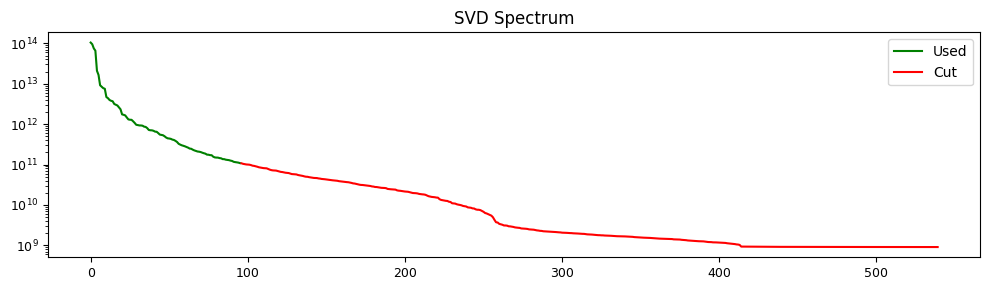

  LM inner 1: chi² 5.8069e+03 (previous 7.0583e+03), λ=0.001
Chi² after correction: 5.8069e+03

==== Iteration 2/2 – LM ====
[Jacobian] File exists, but recomputing as requested (force_recompute=True).
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/EBS/EBS_MDT_16Jan_2026/output/quad_jacobian_logs2.txt'
[Jacobian] Computing skew-quadrupole Jacobian (iteration 2)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/EBS/EBS_MDT_16Jan_2026/output/skew_jacobian_logs.txt'
   No outliers in the data set.
Initial Chi²: 5.8069e+03


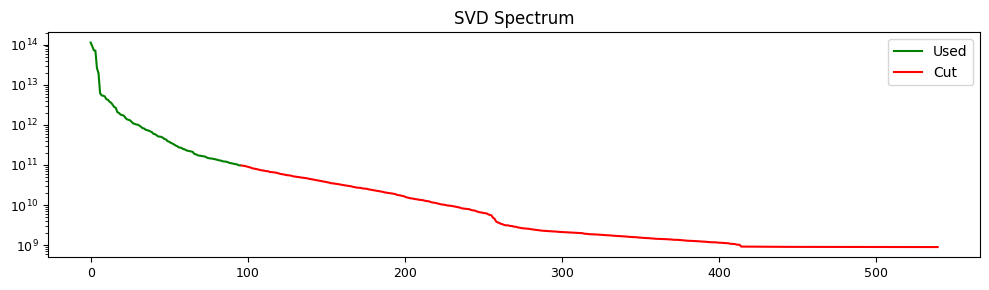

  LM inner 1: chi² 7.3004e+03 (previous 5.8069e+03), λ=0.001


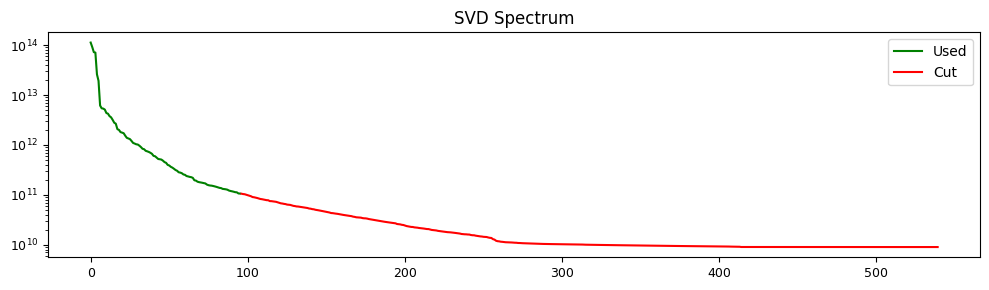

  LM inner 2: chi² 7.1165e+03 (previous 5.8069e+03), λ=0.01


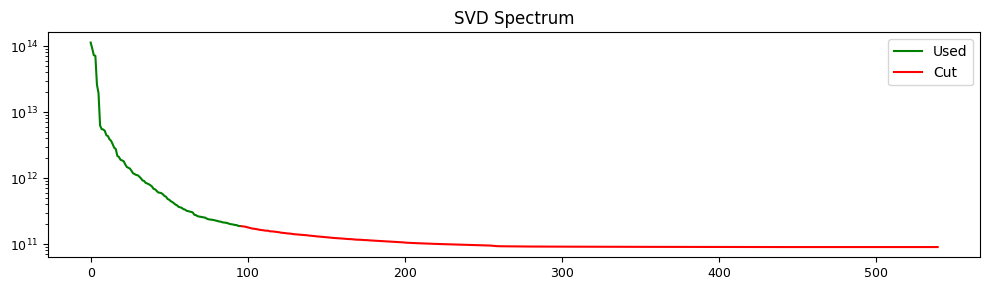

  LM inner 3: chi² 6.2981e+03 (previous 5.8069e+03), λ=0.1


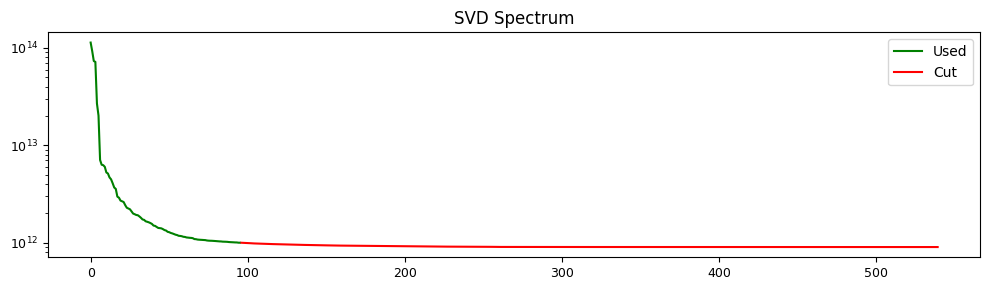

  LM inner 4: chi² 5.8026e+03 (previous 5.8069e+03), λ=1
Chi² after correction: 5.8026e+03
LOCO LM completed! :).
[info] Saved fit_dict to output_all_err3/fit_results_all_parameters3.json


In [20]:
# In[2]:

fit_cfg = FitInitConfig()
ring.disable_6d()
# --- define arguments ---

nHorCOR = len(Corords[0])
nVerCOR = len(Corords[1])
nHBPM = nVBPM = len(used_bpms_ords)
nIter = 2


fit_list     = [
    "quads",
    'skew_quads' ,
    #'quads_tilt' ,
    #"hbpm_gain",
    #"vbpm_gain",
    #"hcor_cal",
    #"vcor_cal",
    #'hbpm_coupling',
    #'vbpm_coupling',
    #'hcor_coupling',
    #'vcor_coupling',
    #'delta_rf'
]

remove_coupling_ = False
includeDispersion = True
hor_dispersion_weight = 100
ver_dispersion_weight = 100

fit_results3, fit_dict3, ring_pyloco3 = pyloco(
    ring_pyloco2,

    # --- general control ---
    algorithm=loco_options.algorithm,
    nIter= nIter,

    # --- indices & number of elements ---
    used_bpms_ords=used_bpms_ords,
    used_cor_ords=Corords,
    quads_ords=quad_indices,
    skew_ords=skew_ord,
    CAVords=CAVords,
    nHBPM=nHBPM,
    nVBPM=nVBPM,
    nHorCOR=nHorCOR,
    nVerCOR=nVerCOR,
    quads_tilt_ind=quad_indices,
    inetial_fit_parameters=None,

    # --- measurement data ---
    orm_measured=measured_orm,
    weights=sigma_w,
    includeDispersion=includeDispersion,
    measured_eta_x=measured_eta_x,
    measured_eta_y=measured_eta_y,
    hor_dispersion_weight=hor_dispersion_weight,
    ver_dispersion_weight=ver_dispersion_weight,

    # --- correctors kicks & RF ---
    CMstep=CMstep,
    rfStep=rf_full_step,
    Frequency=fixed_parameters.Frequency,

    # --- features ---
    fit_list=fit_list,
    individuals=loco_options.individuals,
    remove_coupling_= remove_coupling_,

    # --- outliers & normalization ---
    outlier_rejection=loco_options.outlier_rejection,
    sigma_outlier=loco_options.sigma_outlier,
    apply_normalization=loco_options.apply_normalization,
    normalization_mode=loco_options.normalization_mode,

    # --- SVD selection ---
    svd_selection_method="user_input",
    svd_threshold = loco_options.svd_threshold,
    cut_=96,
    show_svd_plot=loco_options.show_svd_plot,

    # --- LM options ---
    nLMIter=loco_options.nLMIter,
    Starting_Lambda=loco_options.Starting_Lambda,
    max_lm_lambda=loco_options.max_lm_lambda,
    scaled=loco_options.scaled,

    # --- more options ---
    plot_fit_parameters=loco_options.plot_fit_parameters,
    auto_correct_delta=loco_options.auto_correct_delta,
    fixedpathlength= fixedpathlength,
    fit_cfg=fit_cfg,
     fixedmomentum=fixedmomentum,
    # --- Jacopians files ---

    quad_jacobian_file="output_all_err/jacobians/quads/J_quads_iter1_0.0001urad_200Hz.h5",
    skew_jacobian_file=None,
    quads_tilt_jacobian_file=None,
    force_recompute=True,

    continue_from_previous=True,
    previous_fit_results=fit_results2,
    previous_fit_dict=fit_dict2,
    previous_ring=ring_pyloco2
)

# --- save results ---
from pathlib import Path
save_fit_dict(fit_dict3, Path("./output_all_err3/fit_results_all_parameters3"))
ring_pyloco3.save('./output_all_err3/ring_pyloco3.mat', mat_key='ring')

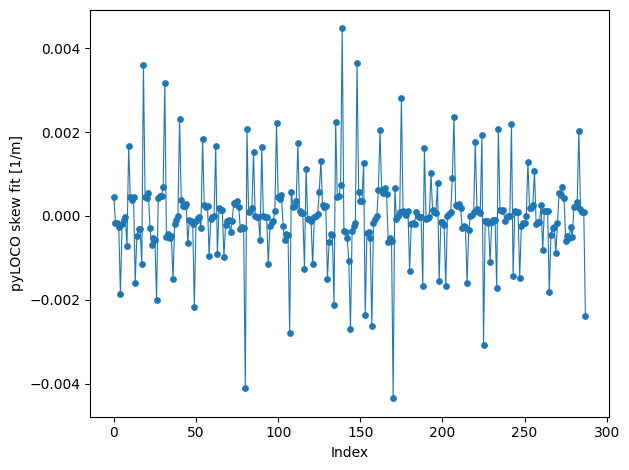

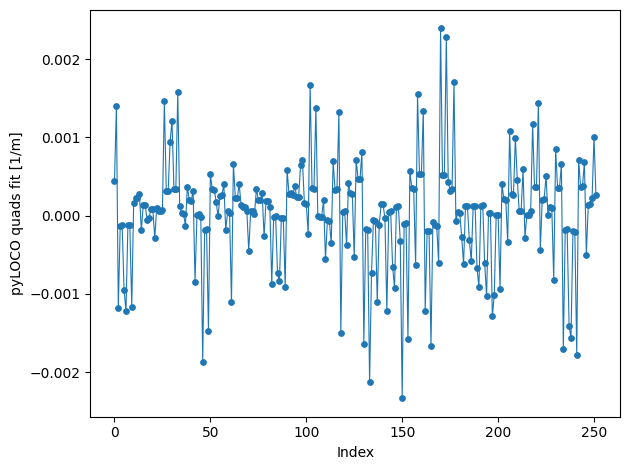

In [21]:
#fit_dict =  json.load(open("./output/fit_results_all_parameters.json")) ##
import matplotlib.pyplot as plt
inner2 = last_by_sorted_key(fit_dict3)
quads_fit2, skew_fit2 = get_quads_block(inner2)

delta_q = np.asarray(
    [(quads_fit2[i] - ring[quad_indices[i]].PolynomB[1]) * ring[quad_indices[i]].Length
     for i in range(len(quad_indices))],
    dtype=float
)

delta_q2 = np.asarray(
    [(skew_fit2[i] - ring[skew_ord[i]].PolynomA[1]) * ring[skew_ord[i]].Length
     for i in range(len(skew_ord))],
    dtype=float
)
x = range(len(delta_q2))

plt.scatter(x, delta_q2, s=15)          # thin points (s = point size)
plt.plot(x, delta_q2, linewidth=0.8)    # thin connecting line

plt.xlabel("Index")
plt.ylabel("pyLOCO skew fit [1/m]")
plt.tight_layout()
plt.show()


import matplotlib.pyplot as plt

x = range(len(delta_q))

plt.scatter(x, delta_q, s=15)          # thin points (s = point size)
plt.plot(x, delta_q, linewidth=0.8)    # thin connecting line

plt.xlabel("Index")
plt.ylabel("pyLOCO quads fit [1/m]")
plt.tight_layout()
plt.show()

In [22]:
import json
from pathlib import Path

#fit_dict =  json.load(open("./output/fit_results_all_parameters.json")) ##
inner = last_by_sorted_key(fit_dict3)
quads_fit, skew_fit = get_quads_block(inner)

delta_q = np.asarray(
    [quads_fit[i] - ring[quad_indices[i]].K for i in range(len(quad_indices))],
    dtype=float
).ravel()

length_quad = np.asarray(
    [ring[quad_indices[i]].Length for i in range(len(quad_indices))],
    dtype=float
).ravel()

delta_skew = np.asarray(
    [skew_fit[i] - ring[skew_ord[i]].PolynomA[1] for i in range(len(skew_ord))],
    dtype=float
).ravel()

length_skew = np.asarray(
    [ring[skew_ord[i]].Length for i in range(len(skew_ord))],
    dtype=float
).ravel()

delta_dict = {int(indx): delta for indx, delta in zip(quad_indices, -delta_q)}
deltas_dict = {int(indx): delta for indx, delta in zip(skew_ord, -delta_skew)}

length_dict = {int(indx): length for indx, length in zip(quad_indices, length_quad)}
lengths_dict = {int(indx): length for indx, length in zip(skew_ord, length_skew)}

data_all = {
    "normal_quads": {
        "delta": delta_dict,
        "length": length_dict
    },
    "skew_quads": {
        "delta": deltas_dict,
        "length": lengths_dict
    }
}

output_path = Path("./output")
output_path.mkdir(parents=True, exist_ok=True)

with open(output_path / "quad_skew_deltas_lengths.json", "w") as f:
    json.dump(data_all, f, indent=4)

print(f"Saved to {output_path / 'quad_skew_deltas_lengths.json'}")

Saved to output/quad_skew_deltas_lengths.json


Lattice tune after loco : [0.17218543 0.3477392 ]


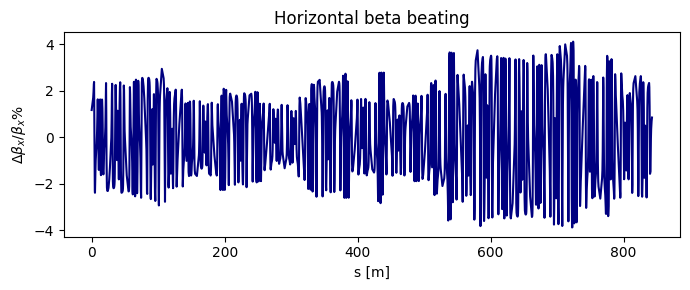

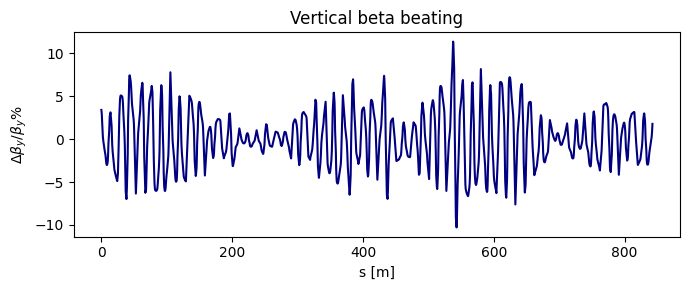

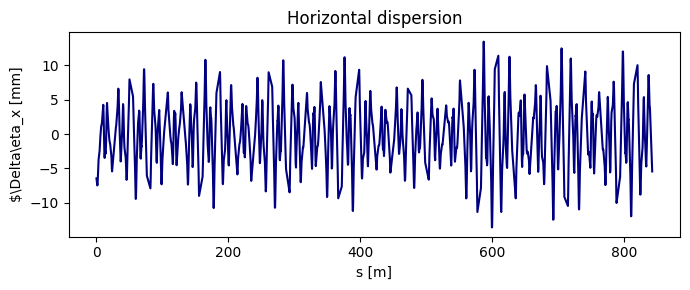

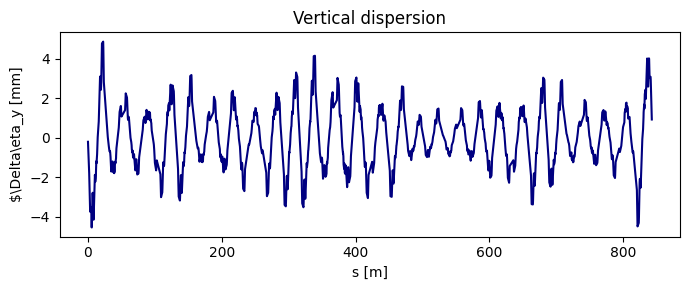

16 Jan 2026, 20:53:29 | WARNING | 'error_table' is missing in the configuration file: ./output_all_err3/betamodel_conf_fitted.yaml. It will be empty!
16 Jan 2026, 20:53:29 | INFO | Loading AT lattice from /Users/elafmusa/Desktop/pyLOCO/Examples/EBS/EBS_MDT_16Jan_2026/output_all_err3/ring_pyloco3.mat
16 Jan 2026, 20:53:32 | INFO | Configuring magnets...
16 Jan 2026, 20:53:32 | INFO | Found 514 (quadrupoles) matching regex '^QD|^QF'
16 Jan 2026, 20:53:33 | INFO | Found 192 (sextupoles) matching regex '^SJ|^SF|^SD|^SI'
16 Jan 2026, 20:53:33 | INFO | Found 64 (octupoles) matching regex '^O'
16 Jan 2026, 20:53:33 | INFO | Found 96 (correctors) matching regex '^SH'
16 Jan 2026, 20:53:33 | INFO | Configuring BPMs...
16 Jan 2026, 20:53:33 | INFO | Found 320 (bpms) matching regex '^BPM'
16 Jan 2026, 20:53:33 | WARNING | No orbit_noise was found for bpms: bpms.
16 Jan 2026, 20:53:33 | WARNING | No tbt_noise was found for bpms: bpms.
16 Jan 2026, 20:53:33 | WARNING | No calibration_error was foun

16 Jan 2026, 20:53:58 | INFO | 64/64, (code=DONE), last_corrector=4318/A1L


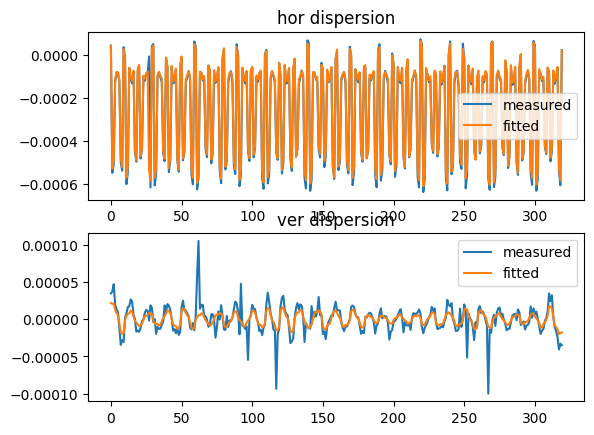

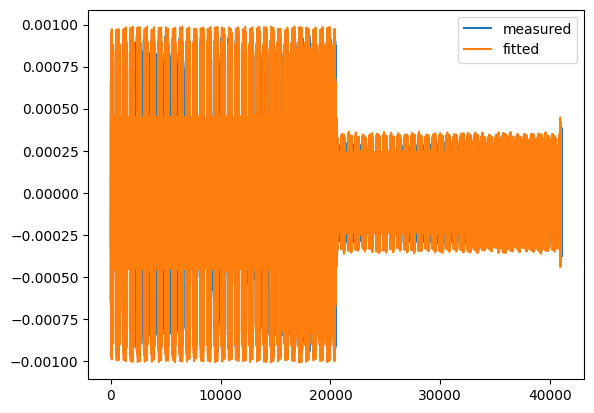

In [25]:
import at
from pyLOCO.pyloco import plot_data
import h5py
import pySC
import logging
import numpy as np
from pySC.apps import measure_ORM
from pySC.apps.interface import pySCOrbitInterface
from pySC.tuning.response_measurements import measure_RFFrequencyOrbitResponse

#logging.getLogger('pySC.apps.response').setLevel(logging.DEBUG)
logger = logging.getLogger(__name__)


ring = at.load_lattice('betamodel.mat', use='betamodel')
ring.disable_6d()
elements_ind = at.get_refpts(ring, "*")
_, _, twiss = at.get_optics(ring, elements_ind)

ring_pyloco3 = at.load_lattice('./output_all_err3/ring_pyloco3.mat', use='ring')
elements_ind = at.get_refpts(ring_pyloco3, "*")

print('Lattice tune after loco :' , at.get_tune(ring_pyloco3))
_, _, twiss_err = at.get_optics(ring_pyloco3, elements_ind)
s_pos = twiss_err.s_pos
bx = (twiss_err.beta[:, 0] - twiss.beta[:, 0]) / twiss.beta[:, 0]
by = (twiss_err.beta[:, 1] - twiss.beta[:, 1]) / twiss.beta[:, 1]
plot_data(s_pos, bx * 100, "s [m]", "$\\Delta\\beta_x / \\beta_x \\%$ ", "Horizontal beta beating")
plot_data(s_pos, by * 100, "s [m]", "$\\Delta\\beta_y / \\beta_y \\%$ ", "Vertical beta beating")

s_pos = twiss_err.s_pos
_, _, twiss = at.get_optics(ring, elements_ind)
dx = (twiss_err.dispersion[:, 0] - twiss.dispersion[:, 0]) #/ twiss.beta[:, 0]
dy = (twiss_err.dispersion[:, 2] - twiss.dispersion[:, 2]) #/ twiss.beta[:, 1]
plot_data(s_pos, dx*1000, "s [m]", "$\\Delta\\eta_x [mm]$", "Horizontal dispersion")
plot_data(s_pos, dy*1000, "s [m]", "$\\Delta\\eta_y [mm]$", "Vertical dispersion")


# use pySC to measure dispersion and ORM on model

# needs ring_pyLOCO.mat
SC = pySC.generate_SC('./output_all_err3/betamodel_conf_fitted.yaml', seed=1, sigma_truncate=3)
interface = pySCOrbitInterface(SC=SC)

eta =  measure_RFFrequencyOrbitResponse(SC, delta_frf =200, normalize = False, bipolar=True)

indices = at.get_uint32_index(ring_pyloco, 'S[FIJ]2A')

corrector_names= [str(int(idx)) + '/B1L' for idx in indices] + [str(int(idx)) + '/A1L' for idx in indices]

generator = measure_ORM(interface=interface, corrector_names=corrector_names, delta=100e-6,
                        shots_per_orbit=1, bipolar=True, skip_save=True)

for code, measurement in generator:
    logger.info(f"{measurement.last_number+1}/{len(corrector_names)}, (code={code.name}), last_corrector={measurement.last_input}")

ORM_fit = measurement.response_data.not_normalized_response_matrix

fig, ax = plt.subplots(nrows=2)
ax[0].plot(measured_eta_x_, label='measured')
ax[0].plot(eta[0:320], label='fitted')
ax[0].set_title('hor dispersion')
ax[0].legend()
ax[1].plot(measured_eta_y_, label='measured')
ax[1].plot(eta[320:640], label='fitted')
ax[1].set_title('ver dispersion')
ax[1].legend()


fig, ax = plt.subplots()
ax.plot(measured_orm.flatten(), label='measured')
ax.plot(ORM_fit.flatten(), label='fitted')
ax.legend()
plt.show()

In [1]:

with h5py.File("./data/ORM_for_pyLOCO_20260116_191907.h5", "r") as f:
    measured_orm = np.array(f["response_matrix"])  # [BPMs x COR]
    delta_correctors = np.array(f["full_delta"])

#measured_orm, removed = remove_bad_bpms(
#    measured_orm,
#    bad_bpm_positions,
#    total_bpms=len(used_bpm),
#    axis=0,
#    input_type="positions"
#)
fig, ax = plt.subplots()
ax.plot(measured_orm.flatten(), label='measured')
ax.plot(ORM_fit.flatten(), '--', label='fitted')
ax.set_xlim(0, 5000)
ax.legend()
plt.show()

NameError: name 'h5py' is not defined

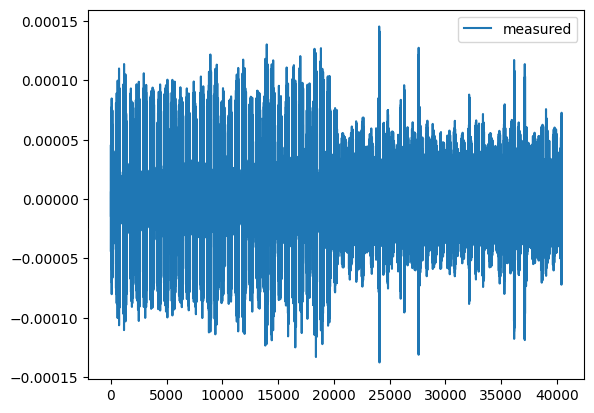

In [46]:

with h5py.File("./data/ORM_for_pyLOCO_20260116_191907.h5", "r") as f:
    measured_orm = np.array(f["response_matrix"])  # [BPMs x COR]
    delta_correctors = np.array(f["full_delta"])

measured_orm, removed = remove_bad_bpms(
    measured_orm,
    bad_bpm_positions,
    total_bpms=len(used_bpm),
    axis=0,
    input_type="positions"
)

ORM_fit, removed = remove_bad_bpms(
    ORM_fit,
    bad_bpm_positions,
    total_bpms=len(used_bpm),
    axis=0,
    input_type="positions"
)

fig, ax = plt.subplots()
ax.plot(measured_orm.flatten() - ORM_fit.flatten(), label='measured')
ax.legend()
plt.show()

In [47]:
rms_diff = np.sqrt(np.mean((ORM_fit - measured_orm)**2))

In [48]:
rms_diff

np.float64(2.8032809733199974e-05)

In [36]:
np.shape(ORM_fit)

(640, 64)

In [37]:
np.shape(measured_orm)

(632, 64)

In [38]:
len(used_bpm)

320

In [64]:
KLs0 = np.load('KLs0.npy')

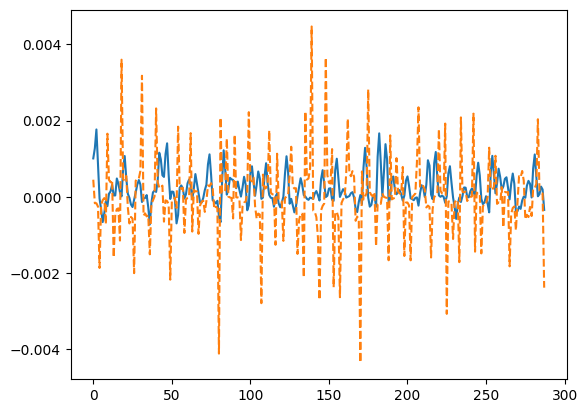

In [68]:
plt.plot(KLs0)
plt.plot(delta_q2, '--')